In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# load data
sales_df = pd.read_csv(
    "../../data/processed/Online_Sales_with_VIP.csv",
    parse_dates=["Transaction_Date"]
)

final_df = pd.read_csv(
    "../../data/processed/final_integrated_data_unscaled.csv"
)


In [2]:

# - Data ranges reasonable?
# basic sanity
# check duplicate CustomerID
assert final_df["CustomerID"].is_unique, "Duplicate CustomerID detected"

# check missing values
df = final_df
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values")
else:
    percent = (missing / len(df)) * 100
    result = pd.DataFrame({
        "MissingCount": missing,
        "MissingPercent": percent
    }).sort_values("MissingPercent", ascending=False)
    display(result)

# check data range
invalid_recency = df[df["Recency"] < 0]
invalid_freq = df[df["Frequency"] < 1]
invalid_monetary = df[df["Monetary"] < 0]
invalid_coupon = df[(df["Coupon_Ratio"] < 0) | (df["Coupon_Ratio"] > 1)]
invalid_tenure = df[df["Tenure_Months"] < 0]
display(df[["Recency", "Frequency", "Monetary", "Coupon_Ratio", "Tenure_Months"]].describe())

No missing values


,Recency,Frequency,Monetary,Coupon_Ratio,Tenure_Months
count,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000
mean,145.292234,18.141008,3560.919407,0.339179,25.912125
std,101.936959,24.976414,5613.006064,0.166418,13.959667
min,1.000000,1.000000,7.000000,0.000000,2.000000
25%,56.000000,5.000000,765.515000,0.264567,14.000000
50%,132.000000,11.000000,1952.680000,0.333333,26.000000
75%,221.000000,23.000000,4362.010000,0.400000,38.000000
max,365.000000,328.000000,83112.260000,1.000000,50.000000


### Sanity check result

No missing values were detected. All numerical features fall within valid ranges, indicating consistent data quality suitable for downstream modeling.

In [3]:
# partial day check
daily_volume = sales_df.groupby(sales_df['Transaction_Date'].dt.date).size()
print(f"daily volume (7 days): {daily_volume.tail(7)}")

# future leakage check
date_columns = sales_df.select_dtypes(include=['datetime64', 'datetimetz']).columns
snapshot_date = sales_df["Transaction_Date"].max() + pd.Timedelta(days=1)
leakage_found = False
for col in date_columns:
    future_leaks = sales_df[sales_df[col] >= snapshot_date]
    if not future_leaks.empty:
        print(f"[WARNING] Column '{col}' contains {len(future_leaks)} rows from the future!")
        leakage_found = True

if not leakage_found:
    print("No future datetime detected beyond the snapshot_date.")

# Time-series Integrity Check
# Sort data chronologically by transaction date
sales_df = sales_df.sort_values('Transaction_Date')
# Calculate the time gap (in days) between consecutive transactions
time_gaps = sales_df['Transaction_Date'].diff().dt.total_seconds() / (24 * 3600)
print("--- Time Gaps Between Transactions (in days) ---")
print(time_gaps.describe())

daily volume (7 days): Transaction_Date
2019-12-25     79
2019-12-26     72
2019-12-27    103
2019-12-28     80
2019-12-29     89
2019-12-30     61
2019-12-31     67
dtype: int64
No future datetime detected beyond the snapshot_date.
--- Time Gaps Between Transactions (in days) ---
count    52923.000000
mean         0.006878
std          0.082648
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Transaction_Date, dtype: float64


### Time Consistency Check

Daily transaction volumes are stable across recent days, indicating no partial-day data issues.
No future timestamps were detected beyond the snapshot date, confirming the absence of temporal leakage.
Time gap statistics reflect daily-level granularity rather than true transaction intervals.

In [4]:
SNAPSHOT_DATE = sales_df["Transaction_Date"].max() + pd.Timedelta(days=1)
cutoff_30d = SNAPSHOT_DATE - pd.Timedelta(days=30)

# recent behavior features
recent_sales = sales_df[sales_df["Transaction_Date"] >= cutoff_30d]

recent_features = recent_sales.groupby("CustomerID").agg(
    Orders_last_30d=("Transaction_ID", "nunique"),
    Spend_last_30d=("Transaction_Value", "sum")
).reset_index()

enriched_df = pd.merge(final_df, recent_features, on="CustomerID", how="left")

# Fill missing (no activity in last 30 days)
enriched_df["Orders_last_30d"] = enriched_df["Orders_last_30d"].fillna(0)
enriched_df["Spend_last_30d"] = enriched_df["Spend_last_30d"].fillna(0)

print(enriched_df[["Orders_last_30d", "Spend_last_30d"]].describe())


       Orders_last_30d  Spend_last_30d
count      1468.000000     1468.000000
mean          1.837875      372.973399
std           7.035765     1610.037317
min           0.000000        0.000000
25%           0.000000        0.000000
50%           0.000000        0.000000
75%           0.000000        0.000000
max         139.000000    38162.490000


### Recent Behavior Feature Check

The distribution of recent activity features shows a strong zero-inflated pattern, where the majority of customers have no transactions within the last 30 days. This indicates a large proportion of inactive users in the recent period.

Additionally, both `Orders_last_30d` and `Spend_last_30d` exhibit significant right-skewness, with a small subset of customers contributing disproportionately high activity.

The distribution does not indicate a near-zero pattern across all customers, suggesting that the 30-day window is appropriate for capturing recent activity.

In [5]:
# DERIVED FEATURES

# Binary indicator for recent activity
enriched_df["Active_30d"] = (enriched_df["Orders_last_30d"] > 0).astype(int)

# Avoid division by zero
enriched_df["Avg_Order_Value"] = np.where(
    enriched_df["Frequency"] > 0,
    enriched_df["Monetary"] / enriched_df["Frequency"],
    0
)

# Purchase interval (days)
enriched_df["Purchase_Interval"] = np.where(
    enriched_df["Frequency"] > 1,
    (enriched_df["Tenure_Months"] * 30.44) / enriched_df["Frequency"],
    enriched_df["Tenure_Months"] * 30.44
)

print(enriched_df[["Avg_Order_Value", "Purchase_Interval"]].describe())

# clean inf / nan
enriched_df.replace([np.inf, -np.inf], 0, inplace=True)

assert not enriched_df.isna().any().any(), "Missing values remain"

       Avg_Order_Value  Purchase_Interval
count      1468.000000        1468.000000
mean        188.690165         155.597530
std         164.712551         253.968225
min           7.000000           0.908657
25%         130.447540          25.269103
50%         172.674286          63.416667
75%         215.284961         152.200000
max        4481.290000        1522.000000


### Data Cleaning Check

No missing or infinite values remain after preprocessing.
Outlier clipping is not applied, as skewness will be addressed using log transformation in the next step.

         Frequency     Monetary  Spend_last_30d  Avg_Order_Value
count  1468.000000  1468.000000     1468.000000      1468.000000
mean      2.461120     7.366484        1.113658         5.072183
std       0.992149     1.490714        2.633559         0.616313
min       0.693147     2.079442        0.000000         2.079442
25%       1.791759     6.641841        0.000000         4.878608
50%       2.484907     7.577468        0.000000         5.157182
75%       3.178054     8.380917        0.000000         5.376597
max       5.796058    11.327960       10.549635         8.407889


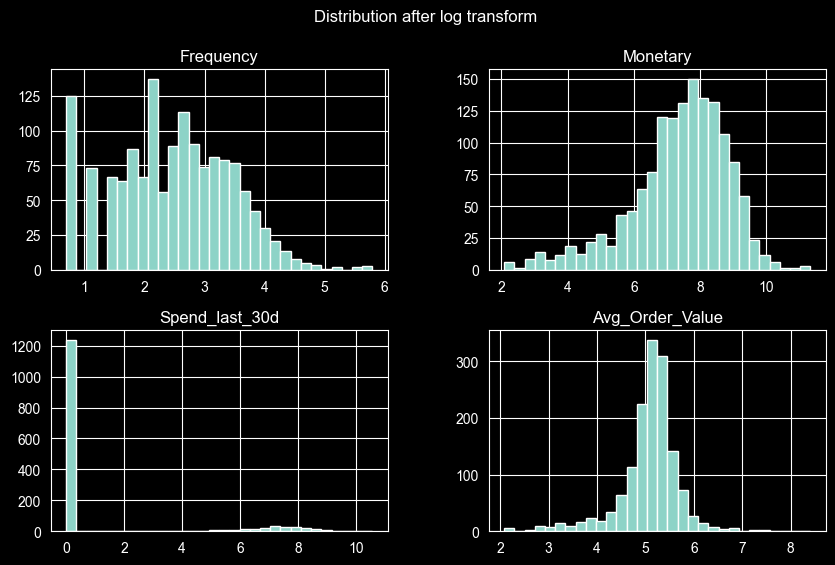

In [6]:
import matplotlib.pyplot as plt

# Log transform for skewed features
cols_to_log = ["Frequency", "Monetary", "Spend_last_30d", "Avg_Order_Value"]

for col in cols_to_log:
    enriched_df[col] = np.log1p(enriched_df[col])

print(enriched_df[cols_to_log].describe())
# histogram
enriched_df[cols_to_log].hist(bins=30, figsize=(10, 6))
plt.suptitle("Distribution after log transform")
plt.show()

### Transform Effect Check

After log transformation, the distributions of skewed features become more compact and less right-skewed.

`Frequency`, `Monetary`, and `Avg_Order_Value` show balanced distributions without extreme outliers.
`Spend_last_30d` remains zero-inflated, which is expected due to inactive customers.

Overall, the transformed features are suitable for downstream modeling.

### Additional Feature: Active_30d

The distribution of `Orders_last_30d` is highly zero-inflated, with the majority of customers showing no recent activity.

To explicitly capture this behavioral pattern, a binary feature `Active_30d` is introduced to distinguish between active and inactive customers. This enhances the model’s ability to identify recent engagement signals.

In [7]:
features_model = [
    "Recency", "Frequency", "Monetary",
    "Coupon_Ratio", "Tenure_Months",
    "Avg_Order_Value", "Purchase_Interval",
    "Orders_last_30d", "Spend_last_30d",
    "Active_30d"
]

ml_df = enriched_df[["CustomerID"] + features_model]

ml_df.to_csv("../data/processed/ml_features_lightgbm.csv", index=False)


# -------- (B) Clustering dataset (SCALED) --------
features_cluster = [
    "Recency", "Frequency", "Monetary",
    "Avg_Order_Value"
]

scaler = StandardScaler()
scaled_cluster = scaler.fit_transform(enriched_df[features_cluster])

cluster_df = pd.DataFrame(scaled_cluster, columns=features_cluster)
cluster_df.insert(0, "CustomerID", enriched_df["CustomerID"])

cluster_df.to_csv("../data/processed/ml_features_clustering.csv", index=False)